# 02 - When companies become unicorns

**Research question.** When are unicorns minted, and how does that timing differ across sectors? Specifically: how is the population of today's surviving unicorns distributed across the year each company first crossed $1B, and how does that distribution vary by sector?

**Data source.** CB Insights public unicorn tracker - <https://www.cbinsights.com/research-unicorn-companies>. Pulled by `scripts/fetch_data.py`; pull date in `data/raw/_fetch_log.json`.

**Why this question and not "years from founding to unicorn"?** The ideal analysis would be `unicorn_year - founded_year`. But the only public source that ships both for the full unicorn list is CB Insights, and CB Insights does **not** publish `founded_year` for free. Wikipedia has founding years for ~200 of the 1,300+ unicorns - a non-random subsample biased toward famous names. Computing a years-to-unicorn distribution on that subsample would be misleading; we keep the option open at the end of the notebook with a clearly-labeled "subsample" section.

**Survivorship warning - applies throughout.** Everything below is conditional on a company already having become, and still being labeled, a unicorn. The distribution of *founding* dates of unicorns is inherently different from the distribution of founding dates of all startups.


## Reproducibility

The cell below records the package versions and the data-pull metadata that produced everything below. It also installs a hook so every `plt.show()` call also writes the figure to `notebooks/figures/` — that way the PNGs on GitHub are always in sync with the rendered notebook.

In [1]:
# Reproducibility
from __future__ import annotations
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
_log = Path('..') / 'data' / 'raw' / '_fetch_log.json'
_meta = json.loads(_log.read_text())[-1] if _log.exists() else {'date': 'unknown', 'source': 'unknown'}
print(f'python      : {sys.version.split()[0]}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'matplotlib  : {matplotlib.__version__}')
print(f'data source : {_meta.get("source")}')
print(f'pull date   : {_meta.get("date")}')
print('notebook    : 02_time_to_unicorn')

_FIG_SLUG = '02_time_to_unicorn'
_FIG_DIR = Path('figures'); _FIG_DIR.mkdir(parents=True, exist_ok=True)
_FIG_COUNTER = {'n': 0}
_orig_show = plt.show
def _show_and_save(*a, **kw):
    for num in plt.get_fignums():
        _FIG_COUNTER['n'] += 1
        fig = plt.figure(num)
        out = _FIG_DIR / f'{_FIG_SLUG}_fig{_FIG_COUNTER["n"]}.png'
        fig.savefig(out, dpi=140, bbox_inches='tight')
    return _orig_show(*a, **kw)
plt.show = _show_and_save


python      : 3.10.12
pandas      : 2.3.3
numpy       : 2.2.6
matplotlib  : 3.10.8
data source : cbinsights
pull date   : 2026-05-16
notebook    : 02_time_to_unicorn


In [2]:
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')


## 0. Load data

If `data/raw/unicorns.csv` is missing, run from the repo root:

```bash
python scripts/fetch_data.py
```

In [3]:
RAW = Path('..') / 'data' / 'raw' / 'unicorns.csv'
LOG = Path('..') / 'data' / 'raw' / '_fetch_log.json'

if not RAW.exists():
    raise FileNotFoundError(
        f'{RAW} not found. Run `python scripts/fetch_data.py` from the repo root.'
    )

df = pd.read_csv(RAW)
pull_meta = json.loads(LOG.read_text())[-1] if LOG.exists() else {'date': 'unknown', 'source': 'unknown'}
df['unicorn_year_num'] = pd.to_numeric(df['unicorn_year'], errors='coerce')
print(f"Loaded {len(df):,} rows from {pull_meta['source']} (pulled {pull_meta['date']}).")
print(f"unicorn_year non-null: {df['unicorn_year_num'].notna().sum():,} / {len(df):,}")
df['unicorn_year_num'].describe().round(1)


Loaded 1,356 rows from cbinsights (pulled 2026-05-16).
unicorn_year non-null: 1,356 / 1,356


count    1356.0
mean     2021.2
std         2.5
min      2007.0
25%      2020.0
50%      2021.0
75%      2022.0
max      2026.0
Name: unicorn_year_num, dtype: float64

## 1. Distribution of `unicorn_year` across today's surviving unicorns


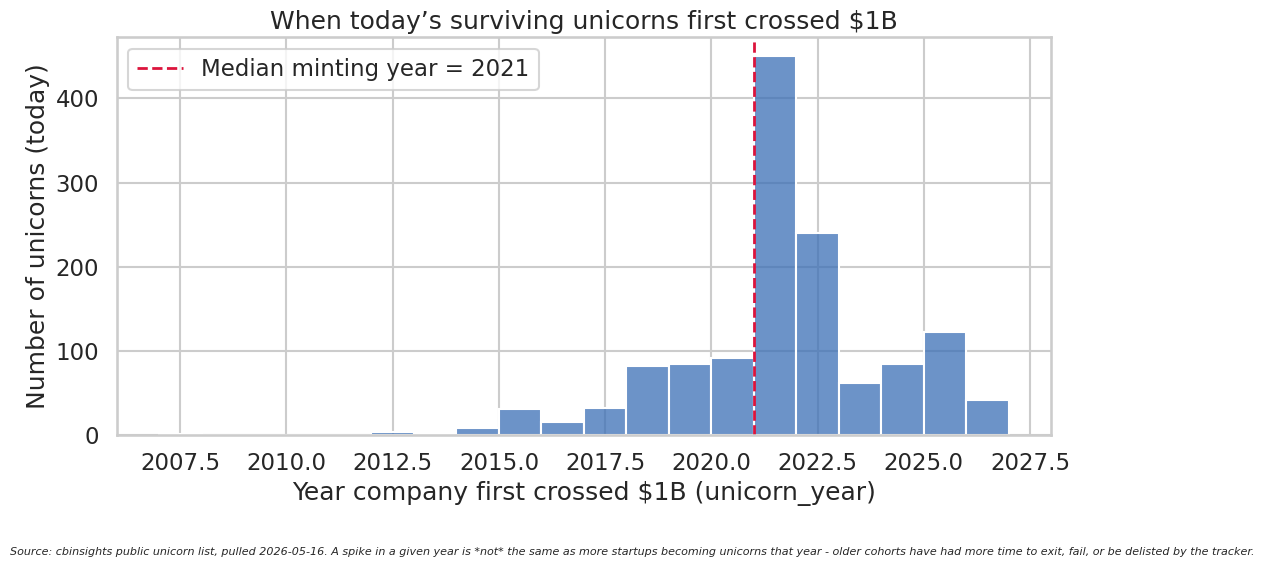

In [4]:
valid = df.dropna(subset=['unicorn_year_num']).copy()
yr_min = int(valid['unicorn_year_num'].min())
yr_max = int(valid['unicorn_year_num'].max())
bins = list(range(yr_min, yr_max + 2))

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.histplot(valid['unicorn_year_num'], bins=bins, ax=ax,
             color='#3b6fb6', edgecolor='white')
med = valid['unicorn_year_num'].median()
ax.axvline(med, color='crimson', linestyle='--', linewidth=2,
           label=f'Median minting year = {med:.0f}')
ax.set_xlabel('Year company first crossed $1B (unicorn_year)')
ax.set_ylabel('Number of unicorns (today)')
ax.set_title('When today\u2019s surviving unicorns first crossed $1B')
ax.legend()
fig.text(0.01, -0.04,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}. "
         'A spike in a given year is *not* the same as more startups becoming unicorns that year - '
         'older cohorts have had more time to exit, fail, or be delisted by the tracker.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## 2. By sector

Within each sector, when were today's surviving unicorns minted?


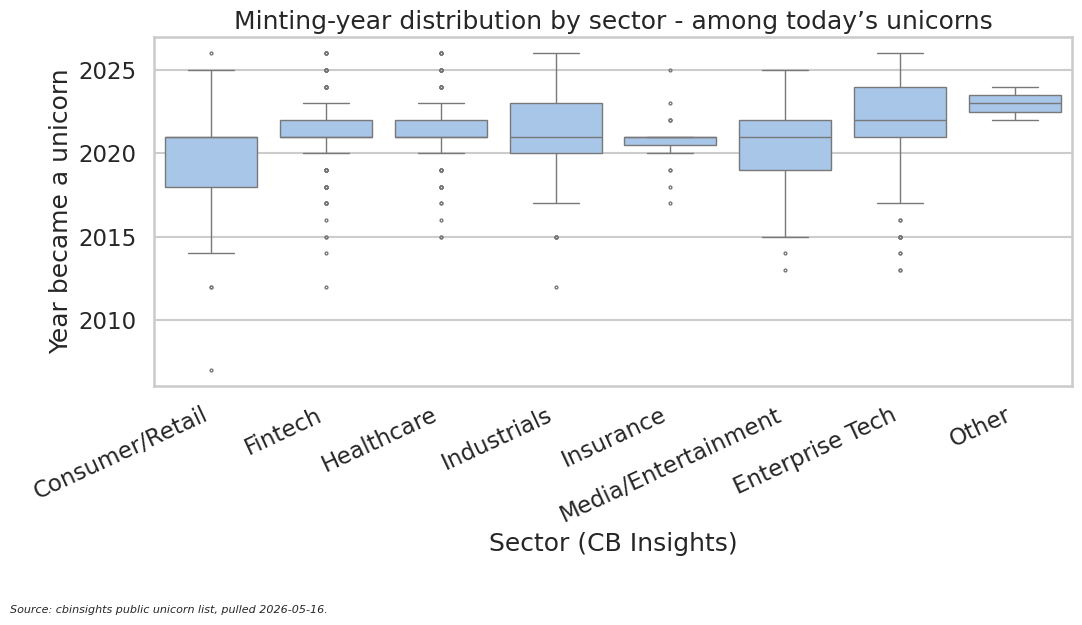

In [5]:
SECTOR_MAP = {
    'Enterprise Tech': 'Enterprise Tech',
    'Financial Services': 'Fintech',
    'Consumer & Retail': 'Consumer/Retail',
    'Industrials': 'Industrials',
    'Healthcare & Life Sciences': 'Healthcare',
    'Media & Entertainment': 'Media/Entertainment',
    'Insurance': 'Insurance',
    'Industrial': 'Industrials',
}

def to_sector(s):
    if pd.isna(s):
        return 'Other'
    return SECTOR_MAP.get(str(s).strip(), 'Other')
valid['sector_grp'] = valid['sector'].apply(to_sector)

order = (
    valid.groupby('sector_grp')['unicorn_year_num']
         .median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=valid, x='sector_grp', y='unicorn_year_num', order=order,
    ax=ax, color='#9ec5f2', fliersize=2,
)
ax.set_xlabel('Sector (CB Insights)')
ax.set_ylabel('Year became a unicorn')
ax.set_title('Minting-year distribution by sector - among today\u2019s unicorns')
ax.tick_params(axis='x', rotation=25)
for lbl in ax.get_xticklabels():
    lbl.set_horizontalalignment('right')
fig.text(0.01, -0.05,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}.",
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## 3. By cohort and region

Stacked count of minting year, split by region.


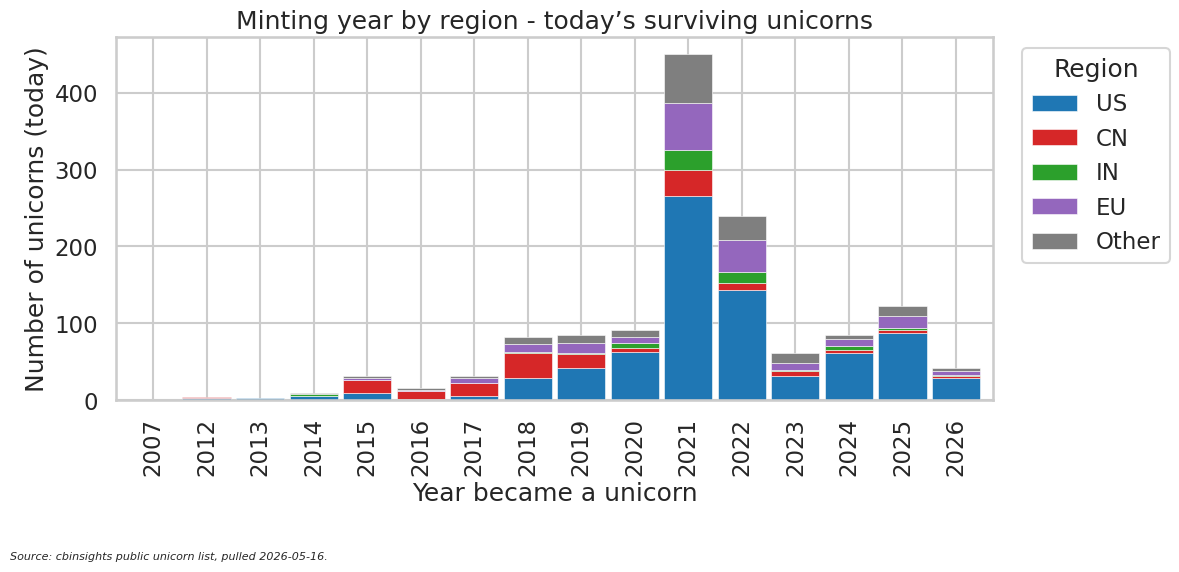

In [6]:
REGION_MAP = {
    'United States': 'US', 'China': 'CN', 'Hong Kong': 'CN',
    'India': 'IN',
    'United Kingdom': 'EU', 'Germany': 'EU', 'France': 'EU',
    'Sweden': 'EU', 'Netherlands': 'EU', 'Spain': 'EU', 'Ireland': 'EU',
    'Switzerland': 'EU', 'Estonia': 'EU', 'Finland': 'EU', 'Denmark': 'EU',
    'Norway': 'EU', 'Italy': 'EU', 'Belgium': 'EU', 'Austria': 'EU',
}
valid['region'] = valid['country'].apply(
    lambda c: REGION_MAP.get(str(c).strip(), 'Other') if pd.notna(c) else 'Other'
)

by_yr_region = (
    valid.assign(unicorn_year_num=valid['unicorn_year_num'].astype(int))
         .groupby(['unicorn_year_num', 'region'])
         .size().unstack(fill_value=0)
         .reindex(columns=['US', 'CN', 'IN', 'EU', 'Other'], fill_value=0)
         .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
by_yr_region.plot(kind='bar', stacked=True, ax=ax,
                  color=['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#7f7f7f'],
                  width=0.9, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Year became a unicorn')
ax.set_ylabel('Number of unicorns (today)')
ax.set_title('Minting year by region - today\u2019s surviving unicorns')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.text(0.01, -0.05,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}.",
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## 4. Optional: years-to-unicorn on a Wikipedia subsample

Wikipedia carries founding years for a *subset* of unicorns. We can compute years-to-unicorn on that subsample, but the subsample is heavily biased toward famous US/EU companies. Read this section as a sanity check, not a population statistic.

This cell is intentionally lazy - it only runs if you have manually added a `founded_year` column to `data/raw/unicorns.csv` (or any compatible file with `company` + `founded_year`).


In [7]:
if 'founded_year' in df.columns and df['founded_year'].notna().sum() > 30:
    sub = df.dropna(subset=['founded_year']).copy()
    sub['founded_year_num'] = pd.to_numeric(sub['founded_year'], errors='coerce')
    sub['years_to_unicorn'] = sub['unicorn_year_num'] - sub['founded_year_num']
    sub = sub[(sub['years_to_unicorn'] >= 0) & (sub['years_to_unicorn'] <= 40)]
    print(f'Subsample with founding-year coverage: n = {len(sub):,}')
    print(f'Median years to unicorn (subsample): {sub["years_to_unicorn"].median():.1f}')
    print('CAVEAT: this subsample is non-random. Do not generalize.')

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(sub['years_to_unicorn'], bins=range(0, 26), ax=ax,
                 color='#3b6fb6', edgecolor='white')
    ax.set_xlabel('Years from founding to unicorn (subsample)')
    ax.set_ylabel('Count')
    ax.set_title('Years to unicorn - Wikipedia subsample only')
    fig.text(0.01, -0.04,
             'Sources: CB Insights for unicorn_year; Wikipedia for founded_year. '
             'Subsample is non-random; not population-representative.',
             fontsize=8, style='italic')
    plt.tight_layout()
    plt.show()
else:
    print(
        'No `founded_year` column with sufficient coverage in unicorns.csv.\n'
        'CB Insights does not publish founding year, and the Wikipedia merge '
        'is intentionally not run by default. To enable: extend scripts/fetch_data.py '
        'to merge Wikipedia founding years (about 200 companies are covered).'
    )


No `founded_year` column with sufficient coverage in unicorns.csv.
CB Insights does not publish founding year, and the Wikipedia merge is intentionally not run by default. To enable: extend scripts/fetch_data.py to merge Wikipedia founding years (about 200 companies are covered).


## What this cannot tell us

- **The hot 2021 cohort is not necessarily "more unicorns minted".**   It is "more unicorns *still labeled* as unicorns from that minting   year". The tracker rarely demotes a unicorn after a private down-round.
- **Failure rates and timing.** We see only unicorns. Companies that   attempted to scale and failed never appear.
- **Years-to-unicorn for the population.** CB Insights does not   publish founding years; the subsample analysis is non-random and   biased toward famous firms.
- **Causal claims about 'AI is faster'.** A right-shifted minting   distribution for a sector could reflect (i) genuinely faster   scaling, (ii) easier 2021-era valuations, (iii) sector being newer,   (iv) selection on which companies get labeled. We cannot separate   these here.
- **Definition drift.** Some firms hit $1B in a primary-market round,   others via SPAC marks, others via secondaries. The tracker does not   distinguish these.


## Save figures

Figures are auto-persisted by the `plt.show` hook installed in the Reproducibility cell at the top. The cell below just lists what was written so the run is self-documenting. Plotly figures are interactive and not exported here.

In [8]:
# Save key figures
from pathlib import Path
_slug = '02_time_to_unicorn'
_written = sorted(Path('figures').glob(f'{_slug}_fig*.png'))
print(f'{len(_written)} figure(s) saved to notebooks/figures/ for {_slug}:')
for p in _written:
    print(f'  {p}')


3 figure(s) saved to notebooks/figures/ for 02_time_to_unicorn:
  figures/02_time_to_unicorn_fig1.png
  figures/02_time_to_unicorn_fig2.png
  figures/02_time_to_unicorn_fig3.png
